# Twenty years of Polish counties, in plain SQL

**380 counties (powiats) over 21 years**: wages, unemployment, population, age and the structure of employment, from the official statistics office (GUS). The question behind it is the one every Polish regional debate comes back to: *are poorer counties catching up, and where does the old map still hold?* The SQL toolbox is regional analysis in miniature: a **view that pivots** a long fact table into a panel, weighted averages, percentiles from `ROW_NUMBER`, rank changes with `RANK()` over two years joined together, a **regression slope and correlation computed from sums** (SQLite has no `CORR`), `NTILE` quartiles to find counties that stay at the bottom year after year, and conditional aggregation by dominant sector. Python only runs the queries and draws the charts.

**Data:** the [GUS Local Data Bank](https://bdl.stat.gov.pl/) API (public statistics). Run `python build_db.py` once: it fetches eleven indicators for all 380 counties (about 45 requests, 2 MB) into a SQLite database, then point `COUNTIES_DB` at that file. The anonymous API has a daily quota, so the script caches responses and waits when it is asked to.

**Reading the data.** The 66 *cities with powiat status* (for example Warsaw, Kraków, Jastrzębie-Zdrój) are counties in their own right and are marked in `is_city`; the other 314 are land counties. Wages are *nominal* (not adjusted for inflation), so growth rates mostly reflect price rises. The national figures here are **population-weighted averages of county values**, an approximation, not the official national rate (which is weighted by the labour force). A value of 0 for a wage or population, which GUS uses for suppressed data, is stored as missing. Median age exists from 2018 and the employment structure from 2022 only. County borders change over the period (Wałbrzych became a city county in 2013, Zielona Góra absorbed its rural neighbour in 2015), so section 2 finds the county series that break and they are left out of the comparisons between years.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("COUNTIES_DB", "poland_counties.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,facts,48603
1,indicators,11
2,powiats,380


## 1. How did Poland look as a whole, 2005 to 2025?

The `panel` view pivots the long `facts` table into one row per county and year. Weighting each county's rate by its population gives an approximate national unemployment rate and average wage, and `LAG()` adds the yearly change.

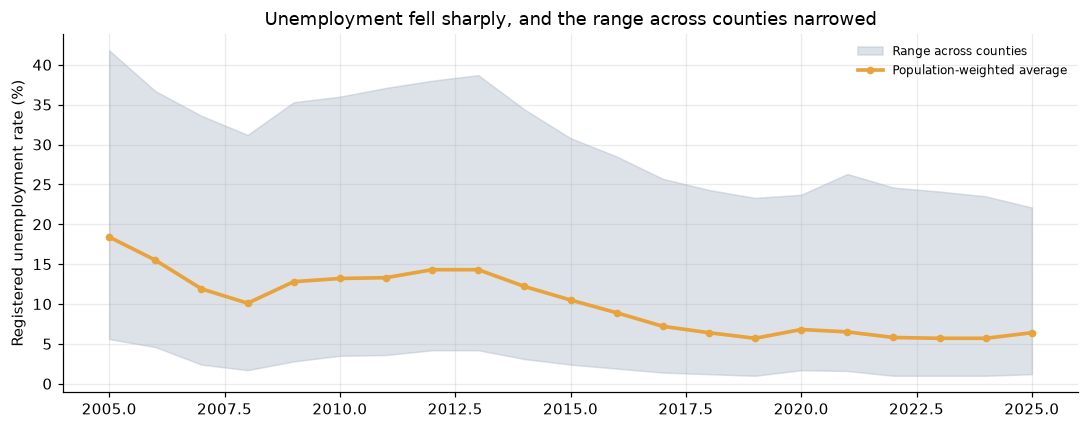

,year,unemployment_pct,avg_wage_pln
0,2005,18.4,2250.0
4,2009,12.8,2970.0
9,2014,12.2,3628.0
14,2019,5.7,4726.0
19,2024,5.7,8005.0
20,2025,6.4,8707.0


In [3]:
national = q("""
SELECT year,
       COUNT(*)                                                           AS counties,
       ROUND(SUM(unemployment * population) / SUM(population), 1)         AS unemployment_pct,
       ROUND(SUM(wage * population) / SUM(population))                    AS avg_wage_pln,
       ROUND(MIN(unemployment), 1)                                        AS lowest_county,
       ROUND(MAX(unemployment), 1)                                        AS highest_county,
       ROUND(SUM(unemployment * population) / SUM(population)
             - LAG(SUM(unemployment * population) / SUM(population)) OVER (ORDER BY year), 1) AS change_pp
FROM panel
WHERE unemployment IS NOT NULL AND population IS NOT NULL AND wage IS NOT NULL
GROUP BY year
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(national.year, national.lowest_county, national.highest_county, color=GREY, alpha=0.35, label="Range across counties")
ax.plot(national.year, national.unemployment_pct, color=AMBER, marker="o", ms=4, lw=2.4, label="Population-weighted average")
ax.set_ylabel("Registered unemployment rate (%)")
ax.set_title("Unemployment fell sharply, and the range across counties narrowed")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
national[["year", "unemployment_pct", "avg_wage_pln"]].iloc[[0, 4, 9, 14, 19, 20]]

## 2. Where do the county series break?

Borders move. When a city leaves a county or two units merge, the county's population jumps from one year to the next. `LAG()` over each county's years finds the jumps larger than 8%. The build script defines the view `series_breaks` with the same logic, and the comparisons between years below leave these counties out.

In [4]:
breaks = q("""
WITH yearly AS (
    SELECT p.name, p.voivodship, f.year, f.population,
           LAG(f.population) OVER (PARTITION BY f.powiat_id ORDER BY f.year) AS previous
    FROM panel f
    JOIN powiats p USING (powiat_id)
)
SELECT name, voivodship, year,
       ROUND(previous, 1)                           AS thousand_before,
       ROUND(population, 1)                         AS thousand_after,
       ROUND(100.0 * (population / previous - 1), 1) AS change_pct
FROM yearly
WHERE ABS(population / previous - 1) > 0.08
ORDER BY year, name
""")

breaks

,name,voivodship,year,thousand_before,thousand_after,change_pct
0,chełmski,Lubelskie,2006,73.6,79.8,8.5
1,krasnostawski,Lubelskie,2006,76.3,69.0,-9.6
2,wałbrzyski,Dolnośląskie,2013,177.6,57.8,-67.4
3,Zielona Góra,Lubuskie,2015,118.9,138.7,16.6
4,zielonogórski,Lubuskie,2015,94.9,75.2,-20.8
5,piaseczyński,Mazowieckie,2020,188.3,206.8,9.8
6,warszawski zachodni,Mazowieckie,2020,118.6,129.9,9.5
7,wrocławski,Dolnośląskie,2020,151.4,174.3,15.1


## 3. Is the gap between counties closing?

SQLite has no percentile function, so each year's counties are numbered with `ROW_NUMBER()` and the first one at or above 10%, 50% and 90% of the count is picked with a conditional `MIN`. The ratio of the 90th to the 10th percentile measures the gap.

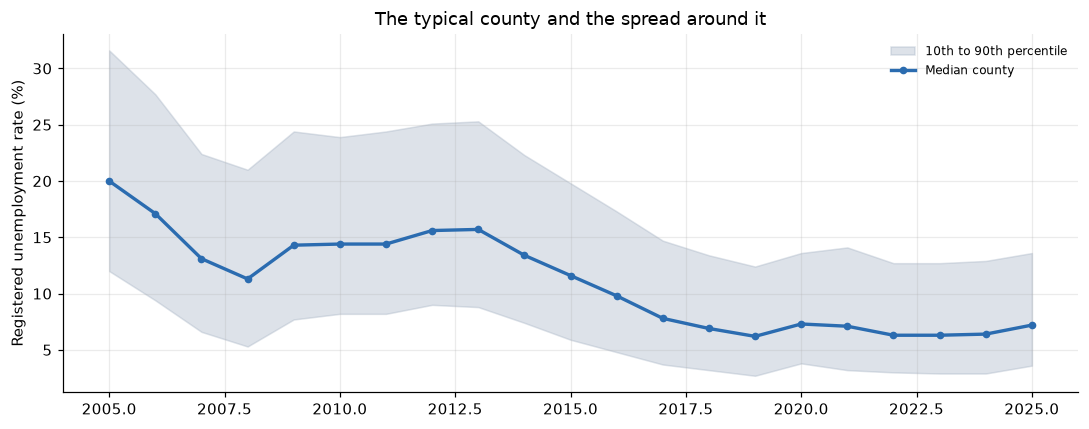

,year,p10,median,p90,gap_pp,ratio
0,2005,12.0,20.0,31.6,19.6,2.6
5,2010,8.2,14.4,23.9,15.7,2.9
10,2015,5.9,11.6,19.8,13.9,3.4
14,2019,2.7,6.2,12.4,9.7,4.6
19,2024,2.9,6.4,12.9,10.0,4.4
20,2025,3.6,7.2,13.6,10.0,3.8


In [5]:
spread = q("""
WITH ranked AS (
    SELECT year, unemployment,
           ROW_NUMBER() OVER (PARTITION BY year ORDER BY unemployment) AS rn,
           COUNT(*)     OVER (PARTITION BY year)                       AS n
    FROM panel
    WHERE unemployment IS NOT NULL
),
pct AS (
    SELECT year,
           MIN(CASE WHEN rn >= 0.10 * n THEN unemployment END) AS p10,
           MIN(CASE WHEN rn >= 0.50 * n THEN unemployment END) AS median,
           MIN(CASE WHEN rn >= 0.90 * n THEN unemployment END) AS p90
    FROM ranked
    GROUP BY year
)
SELECT year, p10, median, p90,
       ROUND(p90 - p10, 1)  AS gap_pp,
       ROUND(p90 / p10, 1)  AS ratio
FROM pct
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(spread.year, spread.p10, spread.p90, color=GREY, alpha=0.35, label="10th to 90th percentile")
ax.plot(spread.year, spread["median"], color=BLUE, marker="o", ms=4, lw=2.2, label="Median county")
ax.set_ylabel("Registered unemployment rate (%)")
ax.set_title("The typical county and the spread around it")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
spread.iloc[[0, 5, 10, 14, 19, 20]]

## 4. Where are the best and the worst paid counties?

`RANK()` in both directions picks the ten highest and ten lowest average gross wages in 2024, and a window average gives each county's wage as an index against the average of the 380 counties.

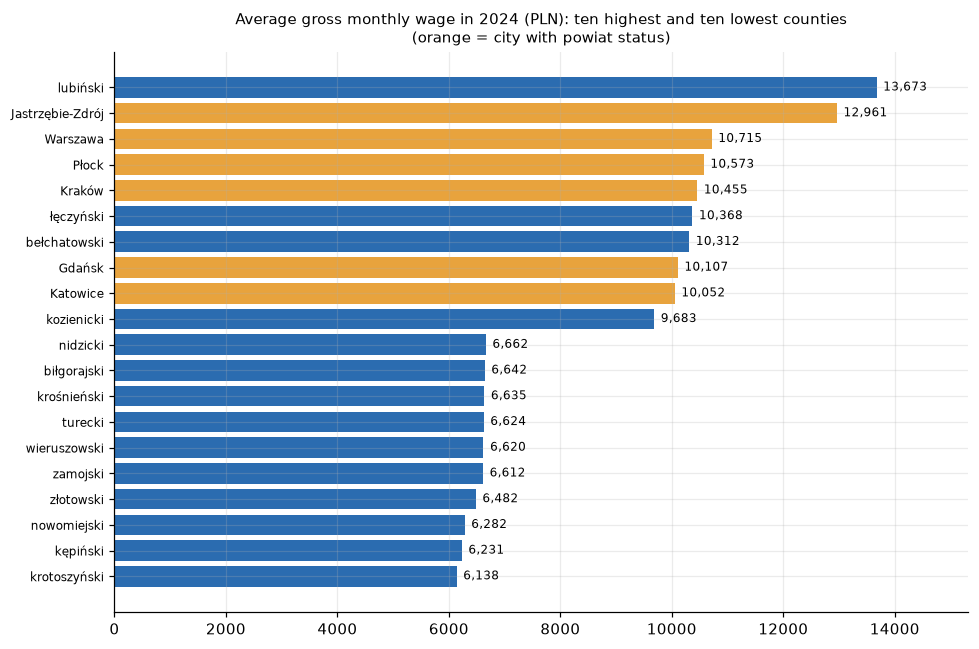

,position,name,voivodship,is_city,wage_pln,index_vs_average
0,1,lubiński,Dolnośląskie,0,13673.0,180.0
1,2,Jastrzębie-Zdrój,Śląskie,1,12961.0,171.0
2,3,Warszawa,Mazowieckie,1,10715.0,141.0


In [6]:
wages_2024 = q("""
WITH w AS (
    SELECT p.name, p.voivodship, p.is_city, ROUND(f.wage) AS wage_pln,
           RANK() OVER (ORDER BY f.wage DESC)          AS rank_high,
           RANK() OVER (ORDER BY f.wage)               AS rank_low,
           ROUND(100.0 * f.wage / AVG(f.wage) OVER ()) AS index_vs_average
    FROM panel f
    JOIN powiats p USING (powiat_id)
    WHERE f.year = 2024
)
SELECT CASE WHEN rank_high <= 10 THEN rank_high ELSE -rank_low END AS position,
       name, voivodship, is_city, wage_pln, index_vs_average
FROM w
WHERE rank_high <= 10 OR rank_low <= 10
ORDER BY wage_pln DESC
""")

fig, ax = plt.subplots(figsize=(9, 6))
colors = [AMBER if c else BLUE for c in wages_2024.is_city]
ax.barh(wages_2024.name[::-1], wages_2024.wage_pln[::-1], color=colors[::-1])
for y, v in enumerate(wages_2024.wage_pln[::-1]):
    ax.text(v + 120, y, f"{v:,.0f}", va="center", fontsize=8)
ax.set_xlim(0, wages_2024.wage_pln.max() * 1.12)
ax.set_title("Average gross monthly wage in 2024 (PLN): ten highest and ten lowest counties\n(orange = city with powiat status)", fontsize=10)
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()
wages_2024.head(3)

## 5. How do the 16 voivodships compare?

Counties are grouped by voivodship and each year is summed separately with conditional aggregation (population-weighted wages and unemployment), so a county that changed shape between 2010 and 2024 does not distort the comparison.

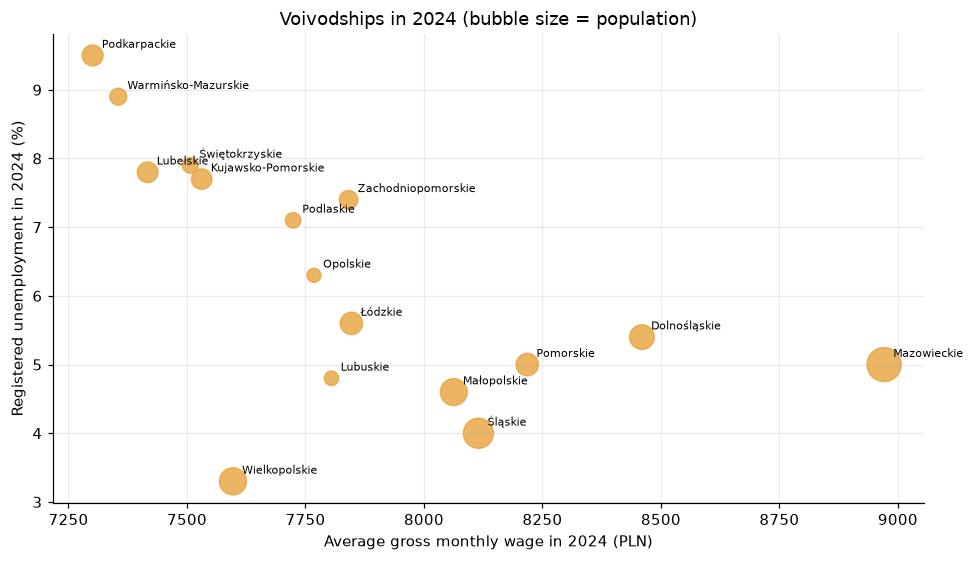

,voivodship,wage_growth_pct,population_change_pct
0,Mazowieckie,146.0,4.6
1,Dolnośląskie,165.0,-1.7
2,Pomorskie,155.0,3.7
3,Śląskie,153.0,-7.4
4,Małopolskie,171.0,2.8
5,Łódzkie,168.0,-7.7
6,Zachodniopomorskie,158.0,-5.9
7,Lubuskie,171.0,-5.2
8,Opolskie,156.0,-8.5
9,Podlaskie,161.0,-5.9


In [7]:
voivodships = q("""
SELECT p.voivodship,
       COUNT(DISTINCT p.powiat_id)                                             AS counties,
       ROUND(SUM(CASE WHEN f.year = 2024 THEN f.population END) / 1000, 2)    AS population_millions,
       ROUND(SUM(CASE WHEN f.year = 2024 THEN f.wage * f.population END)
             / SUM(CASE WHEN f.year = 2024 THEN f.population END))            AS wage_2024,
       ROUND(100.0 * ((SUM(CASE WHEN f.year = 2024 THEN f.wage * f.population END)
                       / SUM(CASE WHEN f.year = 2024 THEN f.population END))
                    / (SUM(CASE WHEN f.year = 2010 THEN f.wage * f.population END)
                       / SUM(CASE WHEN f.year = 2010 THEN f.population END)) - 1)) AS wage_growth_pct,
       ROUND(SUM(CASE WHEN f.year = 2010 THEN f.unemployment * f.population END)
             / SUM(CASE WHEN f.year = 2010 THEN f.population END), 1)         AS unemployment_2010,
       ROUND(SUM(CASE WHEN f.year = 2024 THEN f.unemployment * f.population END)
             / SUM(CASE WHEN f.year = 2024 THEN f.population END), 1)         AS unemployment_2024,
       ROUND(100.0 * (SUM(CASE WHEN f.year = 2024 THEN f.population END)
                      / SUM(CASE WHEN f.year = 2010 THEN f.population END) - 1), 1) AS population_change_pct
FROM panel f
JOIN powiats p USING (powiat_id)
WHERE f.year IN (2010, 2024)
GROUP BY p.voivodship
ORDER BY wage_2024 DESC
""")

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.scatter(voivodships.wage_2024, voivodships.unemployment_2024, s=voivodships.population_millions * 90, color=AMBER, alpha=0.8)
for _, r in voivodships.iterrows():
    ax.annotate(r.voivodship, (r.wage_2024, r.unemployment_2024), textcoords="offset points", xytext=(6, 5), fontsize=7.5)
ax.set_xlabel("Average gross monthly wage in 2024 (PLN)")
ax.set_ylabel("Registered unemployment in 2024 (%)")
ax.set_title("Voivodships in 2024 (bubble size = population)")
fig.tight_layout()
plt.show()
voivodships[["voivodship", "wage_growth_pct", "population_change_pct"]]

## 6. Which counties moved up the pay table, and which fell back?

`RANK()` by wage in 2010 and in 2024, the two results joined on the county, and `ROW_NUMBER` in both directions to keep the eight biggest climbers and the eight biggest fallers.

In [8]:
climbers = q("""
WITH r AS (
    SELECT powiat_id, year, wage,
           RANK() OVER (PARTITION BY year ORDER BY wage DESC) AS pay_rank
    FROM panel
    WHERE year IN (2010, 2024) AND wage IS NOT NULL
      AND powiat_id NOT IN (SELECT powiat_id FROM series_breaks)
),
moves AS (
    SELECT p.name, p.voivodship, p.is_city,
           a.pay_rank AS rank_2010, b.pay_rank AS rank_2024,
           a.pay_rank - b.pay_rank AS places_gained,
           ROUND(a.wage) AS wage_2010, ROUND(b.wage) AS wage_2024,
           ROUND(100.0 * (b.wage / a.wage - 1)) AS growth_pct
    FROM r a
    JOIN r b ON a.powiat_id = b.powiat_id AND a.year = 2010 AND b.year = 2024
    JOIN powiats p ON p.powiat_id = a.powiat_id
),
numbered AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY places_gained DESC) AS best,
              ROW_NUMBER() OVER (ORDER BY places_gained)      AS worst
    FROM moves
)
SELECT name, voivodship, rank_2010, rank_2024, places_gained, wage_2010, wage_2024, growth_pct
FROM numbered
WHERE best <= 8 OR worst <= 8
ORDER BY places_gained DESC
""")

climbers

,name,voivodship,rank_2010,rank_2024,places_gained,wage_2010,wage_2024,growth_pct
0,jaworski,Dolnośląskie,280,61,219,2655.0,8025.0,202.0
1,świebodziński,Lubuskie,292,94,198,2640.0,7823.0,196.0
2,Leszno,Wielkopolskie,257,93,164,2689.0,7825.0,191.0
3,golubsko-dobrzyński,Kujawsko-Pomorskie,279,121,158,2655.0,7647.0,188.0
4,łódzki wschodni,Łódzkie,336,187,149,2554.0,7413.0,190.0
5,sztumski,Pomorskie,317,178,139,2600.0,7425.0,186.0
6,gliwicki,Śląskie,201,67,134,2779.0,7955.0,186.0
7,Legnica,Dolnośląskie,207,74,133,2764.0,7928.0,187.0
8,mrągowski,Warmińsko-Mazurskie,170,315,-145,2824.0,7029.0,149.0
9,pajęczański,Łódzkie,110,269,-159,2951.0,7173.0,143.0


## 7. Are poorer counties catching up?

Regress each county's wage growth on its starting wage, both on a log scale. SQLite has no `CORR` or regression function, but a slope and a correlation both come from six sums: n, Σx, Σy, Σxy, Σx² and Σy². A negative slope means that counties that started lower grew faster, i.e. convergence. Growth runs from each starting year to 2024, so the horizons differ.

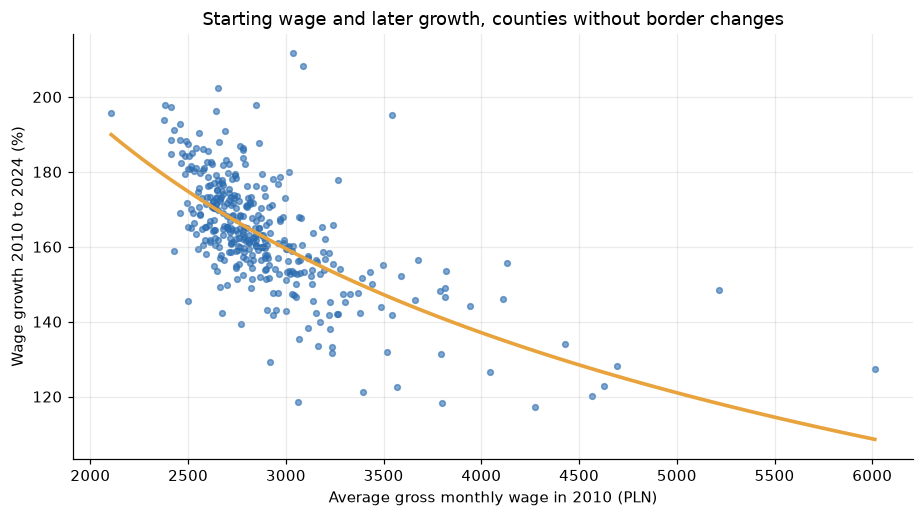

,start_year,counties,slope,correlation
0,2005,371,-0.406,-0.72
1,2010,371,-0.314,-0.66
2,2015,372,-0.298,-0.69
3,2019,372,-0.232,-0.65


In [9]:
convergence = q("""
WITH starts(y0) AS (VALUES (2005), (2010), (2015), (2019)),
pairs AS (
    SELECT s.y0, LN(a.wage) AS x, LN(b.wage / a.wage) AS y
    FROM starts s
    JOIN panel a ON a.year = s.y0
    JOIN panel b ON b.powiat_id = a.powiat_id AND b.year = 2024
    WHERE a.wage > 0 AND b.wage > 0 AND a.powiat_id NOT IN (SELECT powiat_id FROM series_breaks)
),
sums AS (
    SELECT y0, COUNT(*) AS n, SUM(x) AS sx, SUM(y) AS sy, SUM(x * y) AS sxy, SUM(x * x) AS sxx, SUM(y * y) AS syy
    FROM pairs GROUP BY y0
)
SELECT y0                                                                              AS start_year,
       n                                                                               AS counties,
       ROUND((n * sxy - sx * sy) / (n * sxx - sx * sx), 3)                             AS slope,
       ROUND((n * sxy - sx * sy) / SQRT((n * sxx - sx * sx) * (n * syy - sy * sy)), 2) AS correlation
FROM sums
ORDER BY y0
""")

pairs = q("""
SELECT p.name, a.wage AS wage_2010, 100 * (b.wage / a.wage - 1) AS growth_pct
FROM panel a JOIN panel b ON a.powiat_id = b.powiat_id AND a.year = 2010 AND b.year = 2024
JOIN powiats p ON p.powiat_id = a.powiat_id
WHERE a.wage > 0 AND b.wage > 0 AND a.powiat_id NOT IN (SELECT powiat_id FROM series_breaks)
""")
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.scatter(pairs.wage_2010, pairs.growth_pct, s=14, color=BLUE, alpha=0.6)
b1, b0 = np.polyfit(np.log(pairs.wage_2010), np.log1p(pairs.growth_pct / 100), 1)
xs = np.linspace(pairs.wage_2010.min(), pairs.wage_2010.max(), 100)
ax.plot(xs, 100 * (np.exp(b0 + b1 * np.log(xs)) - 1), color=AMBER, lw=2.4)
ax.set_xlabel("Average gross monthly wage in 2010 (PLN)")
ax.set_ylabel("Wage growth 2010 to 2024 (%)")
ax.set_title("Starting wage and later growth, counties without border changes")
fig.tight_layout()
plt.show()
convergence

## 8. Do low unemployment and high wages go together?

The same sums, grouped by year, give the correlation between a county's unemployment rate and the logarithm of its wage in each year, and the correlation between urbanization and unemployment (urbanization is available from 2010).

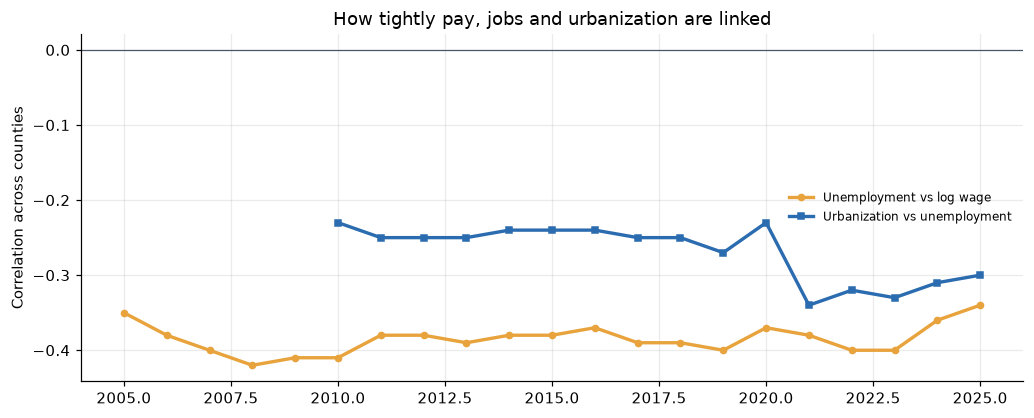

,year,corr_unemployment_wage,corr_urbanization_unemployment
0,2005,-0.35,NaN
5,2010,-0.41,-0.23
10,2015,-0.38,-0.24
15,2020,-0.37,-0.23
20,2025,-0.34,-0.30


In [10]:
jobs_pay = q("""
WITH s AS (
    SELECT year, COUNT(*) AS n,
           SUM(unemployment) AS sx, SUM(LN(wage)) AS sy, SUM(unemployment * LN(wage)) AS sxy,
           SUM(unemployment * unemployment) AS sxx, SUM(LN(wage) * LN(wage)) AS syy
    FROM panel
    WHERE unemployment IS NOT NULL AND wage > 0
    GROUP BY year
),
u AS (
    SELECT year, COUNT(*) AS n,
           SUM(urbanization) AS sx, SUM(unemployment) AS sy, SUM(urbanization * unemployment) AS sxy,
           SUM(urbanization * urbanization) AS sxx, SUM(unemployment * unemployment) AS syy
    FROM panel
    WHERE unemployment IS NOT NULL AND urbanization IS NOT NULL
    GROUP BY year
)
SELECT s.year,
       ROUND((s.n * s.sxy - s.sx * s.sy) / SQRT((s.n * s.sxx - s.sx * s.sx) * (s.n * s.syy - s.sy * s.sy)), 2) AS corr_unemployment_wage,
       ROUND((u.n * u.sxy - u.sx * u.sy) / SQRT((u.n * u.sxx - u.sx * u.sx) * (u.n * u.syy - u.sy * u.sy)), 2) AS corr_urbanization_unemployment
FROM s
LEFT JOIN u USING (year)
ORDER BY s.year
""")

fig, ax = plt.subplots(figsize=(9.5, 3.9))
ax.plot(jobs_pay.year, jobs_pay.corr_unemployment_wage, color=AMBER, marker="o", ms=4, lw=2.2, label="Unemployment vs log wage")
ax.plot(jobs_pay.year, jobs_pay.corr_urbanization_unemployment, color=BLUE, marker="s", ms=4, lw=2.2, label="Urbanization vs unemployment")
ax.axhline(0, color="#4a5568", lw=0.8)
ax.set_ylabel("Correlation across counties")
ax.set_title("How tightly pay, jobs and urbanization are linked")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
jobs_pay.iloc[[0, 5, 10, 15, 20]]

## 9. Which counties grow and which shrink?

Population in 2010 against 2024 for each county, with `ROW_NUMBER` in both directions to list the eight fastest growing and the eight fastest shrinking, together with their 2024 median age.

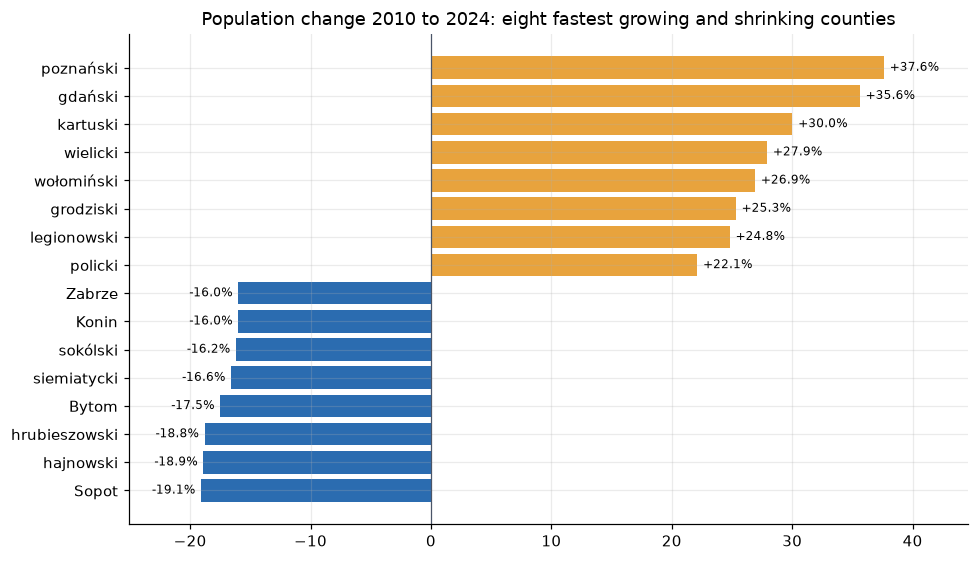

growing     60
total      371
Name: 0, dtype: int64

In [11]:
population = q("""
WITH change AS (
    SELECT p.name, p.voivodship, p.is_city,
           ROUND(a.population, 1)                               AS thousand_2010,
           ROUND(b.population, 1)                               AS thousand_2024,
           ROUND(100.0 * (b.population / a.population - 1), 1) AS change_pct,
           ROUND(b.median_age, 1)                               AS median_age_2024
    FROM panel a
    JOIN panel b ON a.powiat_id = b.powiat_id AND a.year = 2010 AND b.year = 2024
    JOIN powiats p ON p.powiat_id = a.powiat_id
    WHERE a.powiat_id NOT IN (SELECT powiat_id FROM series_breaks)
),
numbered AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY change_pct DESC) AS up,
              ROW_NUMBER() OVER (ORDER BY change_pct)      AS down,
              SUM(change_pct > 0) OVER ()                  AS growing,
              COUNT(*) OVER ()                             AS total
    FROM change
)
SELECT name, voivodship, is_city, thousand_2010, thousand_2024, change_pct, median_age_2024, growing, total
FROM numbered
WHERE up <= 8 OR down <= 8
ORDER BY change_pct DESC
""")

fig, ax = plt.subplots(figsize=(9, 5.2))
colors = [AMBER if v > 0 else BLUE for v in population.change_pct]
ax.barh(population.name[::-1], population.change_pct[::-1], color=colors[::-1])
ax.axvline(0, color="#4a5568", lw=0.8)
for y, v in enumerate(population.change_pct[::-1]):
    ax.text(v + (0.5 if v > 0 else -0.5), y, f"{v:+.1f}%", va="center", ha="left" if v > 0 else "right", fontsize=8)
ax.set_xlim(population.change_pct.min() - 6, population.change_pct.max() + 7)
ax.set_title("Population change 2010 to 2024: eight fastest growing and shrinking counties")
fig.tight_layout()
plt.show()
population[["growing", "total"]].iloc[0]

## 10. Cities and countryside: who is ageing fastest?

Median age exists from 2018. Averaging it by year and by type of county (city with powiat status or land county) shows both the level and the speed of ageing.

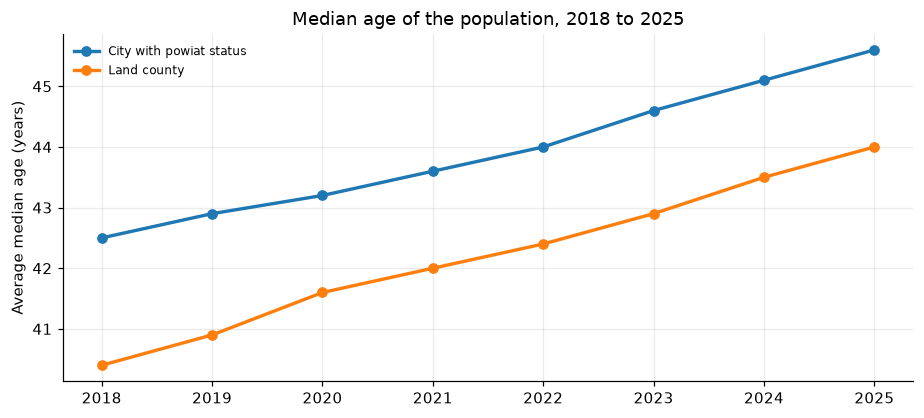

,year,type,counties,avg_median_age,youngest,oldest
0,2018,City with powiat status,66,42.5,38.9,47.3
7,2025,City with powiat status,66,45.6,41.2,49.3
8,2018,Land county,314,40.4,34.6,46.8
15,2025,Land county,314,44.0,37.0,49.7


In [12]:
ageing = q("""
SELECT f.year,
       CASE WHEN p.is_city = 1 THEN 'City with powiat status' ELSE 'Land county' END AS type,
       COUNT(*)                                  AS counties,
       ROUND(AVG(f.median_age), 1)               AS avg_median_age,
       ROUND(MIN(f.median_age), 1)               AS youngest,
       ROUND(MAX(f.median_age), 1)               AS oldest
FROM panel f
JOIN powiats p USING (powiat_id)
WHERE f.median_age IS NOT NULL
GROUP BY f.year, p.is_city
ORDER BY type, f.year
""")

fig, ax = plt.subplots(figsize=(8.5, 3.9))
for t, g in ageing.groupby("type"):
    ax.plot(g.year, g.avg_median_age, marker="o", lw=2.2, label=t)
ax.set_ylabel("Average median age (years)")
ax.set_title("Median age of the population, 2018 to 2025")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
ageing[ageing.year.isin([2018, 2025])]

## 11. What kind of economy does each county have?

From 2022 the data show how employment divides among agriculture, industry, construction, market services and public services. The multi-argument `MAX()` finds each county's largest sector (a `CASE` names it), and the counties are then profiled by that dominant sector.

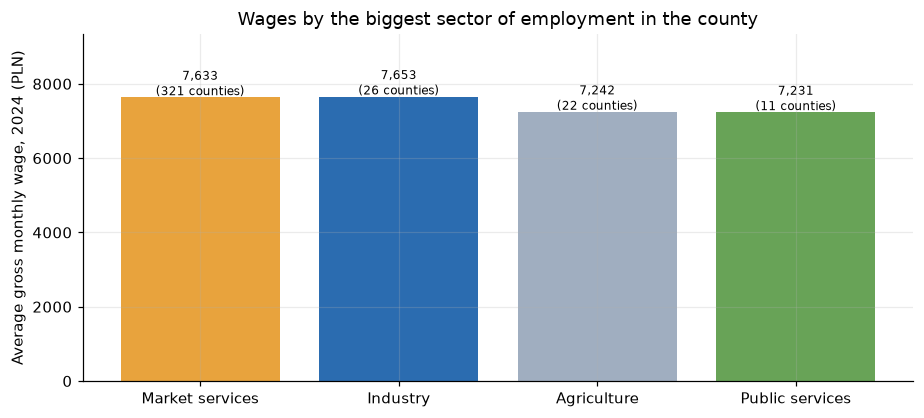

,dominant_sector,counties,avg_top_share_pct,avg_wage_pln,avg_unemployment_pct,avg_median_age
0,Market services,321,38.3,7633.0,7.0,43.7
1,Industry,26,35.3,7653.0,5.9,43.1
2,Agriculture,22,33.3,7242.0,9.5,44.1
3,Public services,11,33.3,7231.0,12.2,45.1


In [13]:
economy = q("""
WITH c AS (
    SELECT f.*, MAX(emp_agriculture, emp_industry, emp_construction, emp_services, emp_public) AS top_share
    FROM panel f
    WHERE f.year = 2024 AND f.emp_services IS NOT NULL
),
labelled AS (
    SELECT *, CASE WHEN emp_services = top_share THEN 'Market services'
                   WHEN emp_industry = top_share THEN 'Industry'
                   WHEN emp_agriculture = top_share THEN 'Agriculture'
                   WHEN emp_public = top_share THEN 'Public services'
                   ELSE 'Construction' END AS dominant
    FROM c
)
SELECT dominant                              AS dominant_sector,
       COUNT(*)                              AS counties,
       ROUND(AVG(top_share), 1)              AS avg_top_share_pct,
       ROUND(AVG(wage))                      AS avg_wage_pln,
       ROUND(AVG(unemployment), 1)           AS avg_unemployment_pct,
       ROUND(AVG(median_age), 1)             AS avg_median_age
FROM labelled
GROUP BY dominant
ORDER BY counties DESC
""")

fig, ax = plt.subplots(figsize=(8.5, 3.9))
ax.bar(economy.dominant_sector, economy.avg_wage_pln, color=[AMBER, BLUE, GREY, "#68a357", "#b794f4"][:len(economy)])
for x, (w, n) in enumerate(zip(economy.avg_wage_pln, economy.counties)):
    ax.text(x, w + 60, f"{w:,.0f}\n({n} counties)", ha="center", fontsize=8)
ax.set_ylim(0, economy.avg_wage_pln.max() * 1.22)
ax.set_ylabel("Average gross monthly wage, 2024 (PLN)")
ax.set_title("Wages by the biggest sector of employment in the county")
fig.tight_layout()
plt.show()
economy

## 12. Which counties are at the bottom year after year?

`NTILE(4)` splits the counties into quartiles by unemployment in each year. Counting the years a county spends in the worst quartile finds those that never left it in 21 years, and `COUNT(*) OVER ()` reports how many there are.

In [14]:
persistent = q("""
WITH q AS (
    SELECT powiat_id, year, unemployment,
           NTILE(4) OVER (PARTITION BY year ORDER BY unemployment DESC) AS quartile
    FROM panel
    WHERE unemployment IS NOT NULL
)
SELECT p.name, p.voivodship,
       COUNT(*)                         AS years,
       SUM(q.quartile = 1)              AS years_in_worst_quartile,
       ROUND(AVG(q.unemployment), 1)    AS avg_unemployment,
       COUNT(*) OVER ()                 AS persistent_total
FROM q
JOIN powiats p USING (powiat_id)
GROUP BY q.powiat_id
HAVING years = 21 AND years_in_worst_quartile = 21
ORDER BY avg_unemployment DESC
LIMIT 12
""")

persistent

,name,voivodship,years,years_in_worst_quartile,avg_unemployment,persistent_total
0,szydłowiecki,Mazowieckie,21,21,30.3,38
1,braniewski,Warmińsko-Mazurskie,21,21,25.8,38
2,bartoszycki,Warmińsko-Mazurskie,21,21,25.2,38
3,białogardzki,Zachodniopomorskie,21,21,24.2,38
4,łobeski,Zachodniopomorskie,21,21,24.0,38
5,kętrzyński,Warmińsko-Mazurskie,21,21,24.0,38
6,radomski,Mazowieckie,21,21,23.8,38
7,piski,Warmińsko-Mazurskie,21,21,23.2,38
8,węgorzewski,Warmińsko-Mazurskie,21,21,23.2,38
9,choszczeński,Zachodniopomorskie,21,21,22.5,38


## What the queries say

- **Unemployment fell by about two thirds, then stopped falling.** The population-weighted rate went from 18.4% in 2005 to 10.1% in 2008, back up to 14.3% in 2012-13, and down to 5.7% in 2019. It was still 5.7% in 2024 and 6.4% in 2025. The average wage (nominal) rose from about 2,250 PLN to 8,005 PLN between 2005 and 2024, and it grew by 30% in the last two years alone (6,161 PLN in 2022).
- **County borders move, and eight series break.** Wałbrzych city left its county in 2013 (the county's population fell by 67%), Zielona Góra absorbed its rural neighbour in 2015 (+17% for the city, -21% for the county), and Wrocław, Piaseczno and Warszawa-West counties jump by 9.5 to 15% in 2020, for a reason that the data do not give. Without this check, Wałbrzych county would show up as the biggest population loser in the country. These counties are left out of the comparisons between years, which also removes Wrocław and Piaseczno counties from the fast-growing list.
- **The gap between counties shrank in points but not in proportion.** The distance between the 10th and the 90th percentile county fell from 19.6 points in 2005 to about 10 points since 2019. But the 90th percentile county has about 4.4 times the unemployment of the 10th, against 2.6 times in 2005, so the worst counties did not catch up in relative terms; the whole distribution simply moved down.
- **Counties with a low starting wage grew faster.** Across 371 counties the slope of (log) wage growth on the starting wage is -0.41 from 2005 (correlation -0.72), -0.31 from 2010 and -0.23 from 2019, so catching up is clear but its pace is slowing. Two cautions: a county whose wage was temporarily low in the starting year tends to bounce back, which exaggerates convergence, and wages are nominal, so a large part of every county's growth is inflation.
- **Pay depends on employers as much as on places.** The highest average wage in 2024 is in Lubin county (13,673 PLN, 180% of the average), followed by Jastrzębie-Zdrój, Warsaw, Płock and Kraków. Four of the top ten are counties with a copper mine, coal mines or large power stations (Lubin, Łęczna, Bełchatów, Kozienice), which suggests that large industrial employers lift the county average. The lowest are Krotoszyn (6,138 PLN, 81% of average), Kępno and Nowe Miasto Lubawskie, so the full range from top to bottom is only 2.2 to 1.
- **Rank changes are large but cannot be explained from this data.** Jawor county rose from 280th to 61st in the pay table between 2010 and 2024, Świebodzin from 292nd to 94th and Leszno from 257th to 93rd. At the other end Konin county fell from 76th to 362nd, Sejny from 116th to 360th and Bieruń-Lędziny from 74th to 251st. Climbers' wages grew by 186-202% against 118-149% for the fallers. Moves of this size over 14 years may reflect single large employers opening or closing, but the data contain no employer information.
- **Low unemployment and high pay go together only loosely.** The correlation across counties between unemployment and the logarithm of the wage stays between -0.34 and -0.42 in every one of 21 years, so unemployment explains about 15% of the variation in pay. Wielkopolskie has the lowest unemployment of all voivodships (3.3%) but only the tenth highest wage, while Podkarpackie has the highest unemployment (9.5%) and the lowest wage (7,301 PLN). The link between urbanization and unemployment strengthened after 2020 (about -0.25 before, -0.30 to -0.34 since).
- **Only 60 of 371 counties grew between 2010 and 2024, and the fastest all surround big cities.** Poznań county grew by 37.6%, Gdańsk county by 35.6%, Kartuzy by 30.0% and Wieliczka (next to Kraków) by 27.9%, and the next four are Wołomin, Grodzisk Mazowiecki and Legionowo (around Warsaw) and Police (next to Szczecin). The biggest losers are Sopot (-19.1%), Hajnówka (-18.9%), Hrubieszów (-18.8%) and Bytom (-17.5%), and four of the eight biggest losers are cities (Sopot, Bytom, Zabrze, Konin). At voivodship level only Mazowieckie (+4.6%), Pomorskie, Małopolskie and Wielkopolskie gained, and Świętokrzyskie lost 9.7%.
- **Cities are older than the countryside, but the countryside is catching up in age.** The average median age rose from 42.5 to 45.6 years in cities with powiat status and from 40.4 to 44.0 in land counties between 2018 and 2025, narrowing the gap from 2.1 to 1.6 years.
- **Most counties have a mixed economy.** In 2024 market services is the largest sector in 321 of 379 counties, industry in 26, agriculture in 22 and public services in 11, but the biggest sector averages only 33-38% of jobs. Average wages hardly differ by dominant sector (7,231 to 7,653 PLN), while unemployment does: 12.2% where public services dominate (11 counties), 9.5% for agriculture and 5.9% for industry.
- **Thirty-eight counties were in the worst unemployment quartile in every one of the 21 years.** Szydłowiec (average 30.3%) is the worst, followed by a block in Warmia-Masuria (Braniewo, Bartoszyce, Kętrzyn, Pisz, Węgorzewo) and in West Pomerania (Białogard, Łobez, Choszczno, Szczecinek), with Radom and Przysucha in Mazovia. The data show where, not why.

**Limits.** Wages are nominal, and the data do not say whether they are counted by employer location or by residence (the GUS methodology note should be checked). Registered unemployment is not the same as the survey-based rate, and it depends on the rules for registration, which changed over the period. One or two counties are missing a value in some years (for example Jastrzębie-Zdrój for wages in 2022-23), so the weighted national averages in those years leave them out. The 8% threshold for a series break is a judgement: a smaller one flags more counties, and breaks that are real growth (a booming suburb) cannot be told apart from boundary changes without outside information.
